# [LAB 04] 데이터 다루기 - 11. 이상치 처리  

## #01. 준비 작업 

In [3]:
!pip install --upgrade matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2. 라이브러리 참조 

In [4]:
import numpy as np
from jussam import load_data
from pandas import DataFrame 
from pandas import DataFrame
from sklearn.impute import SimpleImputer
from matplotlib import pyplot as plt

### 3. 데이터 가져오기 

In [5]:
origin = load_data("ref_sample")
origin

📚 데이터 정제를 위한 실습용 데이터


,kor,eng,math,sic
name,,,,
철수,98.000,77,88.000,64.000
영희,88.000,120,62.000,72.000
민철,NaN,70,83.000,79.000
수현,63.000,60,31.000,71.000
호영,75.000,50,90.000,NaN
영호,80.000,88,91.000,72.000
용식,82.000,88,NaN,90.000
나영,90.000,92,81.000,NaN
석영,91.000,90,89.000,80.000


## #02. 결측치 정제하기 

### 1. 결측치를 평균으로 대체 

In [6]:
imr = SimpleImputer(missing_values = np.nan, strategy='mean')
df_imr = imr.fit_transform(origin.values)
re_df = DataFrame(df_imr, index= origin.index, columns=origin.columns)
re_df

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,120.000,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,63.000,60.000,31.000,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


## #03. 이상치가 존재하는 변수 확인 

### 1. 상자그림 확인하기 

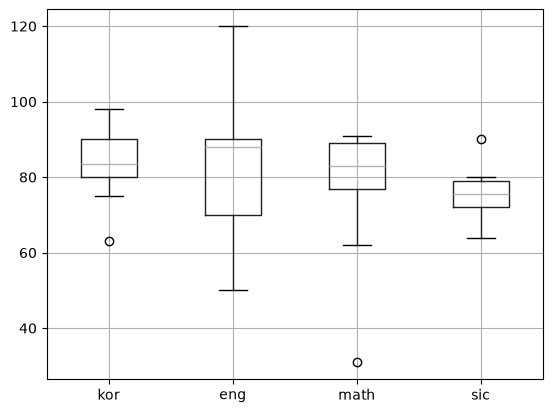

In [7]:
re_df.boxplot()
plt.show()

## #04. 분석가의 주관에 의한 이상치 판별 

### 2. 이상치를 결측치로 변경 

In [8]:
re_df.loc[re_df['eng']>100, 'eng'] = np.nan
re_df

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,NaN,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,63.000,60.000,31.000,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


### 3. 변경된 결측지에 대한 처리 

In [9]:
imr = SimpleImputer(missing_values=np.nan, strategy='mean')
df_imr = imr.fit_transform(re_df.values)
outline_df = DataFrame(df_imr, index=re_df.index, columns=re_df.columns)
outline_df

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,63.000,60.000,31.000,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


## #05. 극단치 경계값을 계산하여 이상치 찾기 

### 1. 사분위간 범위 계산 

In [10]:
outline_df2 = outline_df.copy()
국어Q1 = outline_df['kor'].quantile(0.25)
국어Q3 = outline_df['kor'].quantile(0.75)
국어iqr = 국어Q3 - 국어Q1 
print("국어 점수의 사분위간 범위:", 국어iqr)


국어 점수의 사분위간 범위: 10.0


### 2. 극단치 경계값 찾기 

In [11]:
outline_max = 국어Q3 + 국어iqr*1.5
outline_min = 국어Q3 - 국어iqr*1.5
print("상한 극단치 경계:", outline_max)
print("하한 극단치 경계:", outline_min)


상한 극단치 경계: 105.0
하한 극단치 경계: 75.0


### 3. 극단치 경계값을 활용하여 국어 점수에 대한 하한 이상치 확인 

In [12]:
outline_df2.loc[outline_df2['kor'] < outline_min, 'kor']


name
수현   63.000
Name: kor, dtype: float64

### 4. 국어 점수에 대한 하한 이상치를 결측치로 변환 

In [13]:
outline_df2.loc[outline_df['kor'] < outline_min, 'kor'] = np.nan
outline_df2

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,NaN,60.000,31.000,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


### 5. 국어 점수에 대한 상한 이상치를 결측치로 변환 

In [14]:
outline_df2.loc[outline_df2['kor'] > outline_max, 'kor'] = np.nan
outline_df2 

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,NaN,60.000,31.000,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


### 6. 수학 점수의 극단치 경계값을 활용한 이상치 처리 
- 상자그림으로 확인했을 때, 영어에 대한 이상치는 없었으므로 수학과 과학에 대해서만 처리한다. 

In [15]:
수학Q1 = outline_df2['math'].quantile(0.25)
수학Q3 = outline_df2['math'].quantile(0.75)
수학iqr = 수학Q3 - 수학Q1
outline_max = 수학Q3 - 수학iqr*1.5
outline_min = 수학Q1 - 수학iqr*1.5

outline_df2.loc[outline_df2['math'] < outline_min, 'math'] = np.nan
outline_df2.loc[outline_df2['math'] < outline_max, 'math'] = np.nan
outline_df2

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,NaN,72.000
민철,83.375,70.000,83.000,79.000
수현,NaN,60.000,NaN,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


### 7. 과학 점수의 극단치 경계값을 활용한 이상치 처리 

In [16]:
과학Q1 = outline_df2['sic'].quantile(0.25)
과학Q3 = outline_df2['sic'].quantile(0.75)
과학iqr = 과학Q3 - 과학Q1 
outline_max = 과학Q3 + 과학iqr * 1.5 
outline_min = 과학Q1 - 과학iqr * 1.5 

outline_df2.loc[outline_df2['sic'] < outline_min, 'sic'] = np.nan
outline_df2.loc[outline_df2['sic'] > outline_max, 'sic'] = np.nan
outline_df2

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,NaN,72.000
민철,83.375,70.000,83.000,79.000
수현,NaN,60.000,NaN,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,NaN
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


### 8. 마지막 단계 : 결측치로 변환된 값을 처리한다. 

In [17]:
imr = SimpleImputer(missing_values=np.nan, strategy='mean')
df_imr = imr.fit_transform(outline_df2.values)
final_df = DataFrame(df_imr, index=outline_df2.index, columns=outline_df2.columns)

final_df

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,85.554,72.000
민철,83.375,70.000,83.000,79.000
수현,85.922,60.000,85.554,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,73.607
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


## #06. 이상치를 이상치 경계값으로 대체하기 ( 모든 컬럼 일괄처리 )

In [18]:
# 분석가 주관에 의한 정제 데이터에서 이어서 진행 
outline_df3 = outline_df.copy()

# 컬럼 만큼 반복 
for c in outline_df3.columns:
    # 사분위 구간 계산 
    Q1 = outline_df3[c].quantile(0.25)
    Q3 = outline_df3[c].quantile(0.75)
    iqr = Q3 - Q1 

    # 이상치 경계 계산 
    outline_min = Q1 -iqr * 1.5
    outline_max = Q3 +iqr * 1.5 

    # 이상치 정제 
    outline_df3.loc[outline_df3[c] < outline_min, c] = outline_min
    outline_df3.loc[outline_df3[c] < outline_max, c] = outline_max

outline_df3
    


,kor,eng,math,sic
name,,,,
철수,105.000,115.000,107.188,89.500
영희,105.000,115.000,107.188,89.500
민철,105.000,115.000,107.188,89.500
수현,105.000,115.000,107.188,89.500
호영,105.000,115.000,107.188,89.500
영호,105.000,115.000,107.188,89.500
용식,105.000,115.000,107.188,90.000
나영,105.000,115.000,107.188,89.500
석영,105.000,115.000,107.188,89.500


## #01. 연습문제 - 신비한 식물 성장 기록 연구 

### 데이터 불러오기 및 기본 정보 확인 

### 라이브러리 참조 

In [19]:
import numpy as np 
from jussam import load_data
from pandas import DataFrame 
from sklearn.impute import SimpleImputer
from matplotlib import pyplot as plt

### 요구사항 해결

plant_growth 데이터를 불러와 데이터프레임으로 만드세요. \
데이터프레임의 기본적인 구조와 정보(처음 5개 행, 각 열의 데이터 타입 및 결측치 여부)를 확인하세요 

In [20]:
df = load_data('plant_growth')
df

📚 신비한 식물의 성장 기록 데이터

    field           description
--  --------------  ----------------------------------------
 0  plant_id        식물의 고유 ID(인덱스)
 1  species         식물의 종 (GlowLeaf, SunPetal, AquaRoot)
 2  height_cm       식물의 키 (cm)
 3  sunlight_hours  일일 평균 햇빛 노출 시간
 4  water_ml        일일 평균 물 공급량 (ml)



,species,height_cm,sunlight_hours,water_ml
plant_id,,,,
1,GlowLeaf,15.200,5.100,505
2,GlowLeaf,14.800,4.900,498
3,GlowLeaf,15.500,5.200,510
4,GlowLeaf,110.000,5.000,502
5,GlowLeaf,15.100,4.800,495
6,SunPetal,25.300,8.200,705
7,SunPetal,24.900,8.100,698
8,SunPetal,25.500,8.300,710
9,SunPetal,25.100,8.000,702


In [21]:
df.head(5)

,species,height_cm,sunlight_hours,water_ml
plant_id,,,,
1,GlowLeaf,15.200,5.100,505
2,GlowLeaf,14.800,4.900,498
3,GlowLeaf,15.500,5.200,510
4,GlowLeaf,110.000,5.000,502
5,GlowLeaf,15.100,4.800,495


In [22]:
df.info()

<class 'pandas.DataFrame'>
Index: 20 entries, 1 to 20
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   species         20 non-null     str    
 1   height_cm       20 non-null     float64
 2   sunlight_hours  20 non-null     float64
 3   water_ml        20 non-null     int64  
dtypes: float64(2), int64(1), str(1)
memory usage: 960.0 bytes


In [23]:
df.isnull().sum()

species           0
height_cm         0
sunlight_hours    0
water_ml          0
dtype: int64

### 2. 데이터 시각화를 통한 이상치 탐색 

1) 각 식물 종(species)별로 
height_cm, sunlight_hours, water_ml에 대한 상자 그림(boxplot)을 그려보세요. 

식물 종의 종류를 확인하기 위해서 종류별로 집계 

In [24]:
df['species'].value_counts()

species
GlowLeaf    7
SunPetal    7
AquaRoot    6
Name: count, dtype: int64

### GlowLeaf 유형만 필터링 하여 상자그림 생성 

In [25]:
df_glowleaf = df[df['species'] == 'GlowLeaf']
df_glowleaf

,species,height_cm,sunlight_hours,water_ml
plant_id,,,,
1,GlowLeaf,15.200,5.100,505
2,GlowLeaf,14.800,4.900,498
3,GlowLeaf,15.500,5.200,510
4,GlowLeaf,110.000,5.000,502
5,GlowLeaf,15.100,4.800,495
16,GlowLeaf,14.900,5.300,512
17,GlowLeaf,15.300,5.100,508


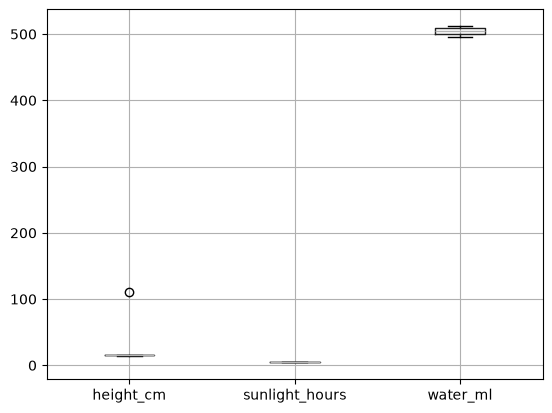

In [26]:
df_glowleaf.boxplot()
plt.show()

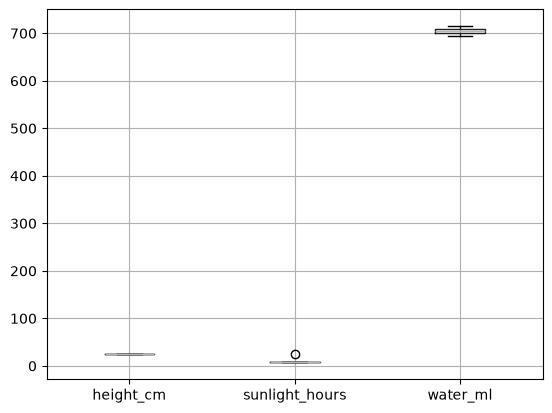

In [27]:
df[df['species'] == 'SunPetal'].boxplot()
plt.show()

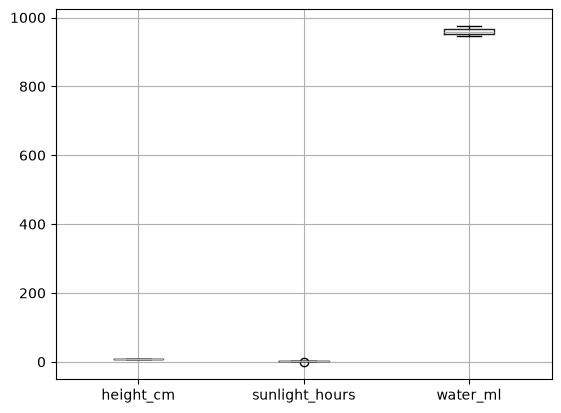

In [28]:
df[df['species'] == 'AquaRoot'].boxplot()
plt.show()

2) 생성된 그래프를 보고 이상치로 의심되는 값들이 어떤 열과 종에 있는지 설명해보세요. 
 - GlowLeaf 종 : 키에 이상치가 검출되었다. 
 - SunPetal 종 : 평균 햇빛 노출 시간에서 이상치가 검출되었다. 
 - AquaRoot 종 : 평균 햇빛 노출 시간에서 이상치가 검출되었다. 

문제 3: IQR을 이용한 이상치 식별 및 정제\
종에 대한 구별 없이 height_cm 열에 대해 IQR을 계산하고, 이를 바탕으로 이상치의 경계(하한, 상한)를 구하세요. 출력할 때는 소수점 둘째 자리까지만 표시하세요. 종에 대한 구별 없는 데이터 셋을 위해서 종을 의미하는 변수를 제거하세요.\
위에서 구한 경계를 벗어나는 이상치를 식별하고, 어떤 값인지 출력하세요.\
sunlight_hours 열에 대해서도 동일한 과정을 반복하여 이상치를 찾아내고, 해당 값을 출력하세요.\
검출된 이상치를 평균값으로 정제하고 결과 데이터셋을 제시하세요.

### 문제 3: IQR을 이용한 이상치 식별 및 정제 

1) 종에 대한 구별없이 height_cm열에 대해 IQR을 계산하고, \
이를 바탕으로 이상치의 경계(하한, 상한)를 구하세요. \
출력할 때는 소수점 2째 자리까지만 표시하세요.\
종에 대한 구별없는 데이터셋을 위해서 종을 의미하는 변수를 제거하세요. 

In [ ]:
df2 = df.drop(columns='species')

height_cm_q1 = df2['height_cm'].quantile(0.25)
height_cm_q3 = df2['height_cm'].quantile(0.75)
height_cm_iqr = height_cm_q3 - height_cm_q1
height_outline_max = height_cm_q3 + height_cm_iqr * 1.5
height_outline_min = height_cm_q1 - height_cm_iqr * 1.5
print("height_cm에 대한 iqr: %.2f, 하한 이상치 경계: %.2f, 상한 이상치 경계: %.2f" % (height_cm_iqr, height_outline_min, height_outline_max))

height_cm에 대한 iqr: 16.45, 하한 이상치 경계: -16.10, 상한 이상치 경계: 49.70


#### 2) 위에서 구한 경계를 벗어나는 이상치를 식별하고, 어떤 값인지 출력하세요.

In [ ]:
df2.loc[(df2['height_cm'] < height_outline_min) | (df2['height_cm'] > height_outline_max)]

,height_cm,sunlight_hours,water_ml
plant_id,,,
4,110.000,5.000,502


#### 3) `sunlight_hours`열에 대해서도 동일한 과정을 반복하여 이상치를 찾아내고, 해당 값을 출력하세요.

In [ ]:
sunlight_hours_q1 = df2['sunlight_hours'].quantile(0.25)
sunlight_hours_q3 = df2['sunlight_hours'].quantile(0.75)
sunlight_hours_iqr = sunlight_hours_q3 - sunlight_hours_q1
sunlight_outline_max = sunlight_hours_q3 + sunlight_hours_iqr * 1.5
sunlight_outline_min = sunlight_hours_q1 - sunlight_hours_iqr * 1.5
print("sunlight_hours에 대한 iqr: %.2f, 하한 이상치 경계: %.2f, 상한 이상치 경계: %.2f" % (sunlight_hours_iqr, sunlight_outline_min, sunlight_outline_max))

df2.loc[(df2['sunlight_hours'] < sunlight_outline_min) | (df2['sunlight_hours'] > sunlight_outline_max)]

sunlight_hours에 대한 iqr: 5.65, 하한 이상치 경계: -6.10, 상한 이상치 경계: 16.50


,height_cm,sunlight_hours,water_ml
plant_id,,,
10,25.400,25.000,708


In [ ]:
df3 = df2.copy()

df3.loc[(df3['height_cm'] < height_outline_min) | (df3['height_cm'] > height_outline_max), 'height_cm'] = np.nan

df3.loc[(df3['sunlight_hours'] < sunlight_outline_min) | (df3['sunlight_hours'] > sunlight_outline_max), 'sunlight_hours'] = np.nan

imr = SimpleImputer(missing_values=np.nan, strategy='mean')
df_imr = imr.fit_transform(df3.values)
final_df = DataFrame(df_imr, index=df3.index,
                     columns=df3.columns)
final_df

,height_cm,sunlight_hours,water_ml
plant_id,,,
1,15.200,5.100,505.000
2,14.800,4.900,498.000
3,15.500,5.200,510.000
4,16.679,5.000,502.000
5,15.100,4.800,495.000
6,25.300,8.200,705.000
7,24.900,8.100,698.000
8,25.500,8.300,710.000
9,25.100,8.000,702.000
